In [ ]:
import numpy as np
import pandas as pd

In [13]:
df=pd.read_csv("/content/Telco-Customer-Churn.csv")
df.sample(25)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5204,4282-ACRXS,Male,1,Yes,No,38,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.85,955.75,No
3147,8903-WMRNW,Female,0,Yes,No,15,Yes,No,Fiber optic,Yes,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,101.75,1669.4,No
5207,9381-NDKME,Female,1,Yes,No,24,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Credit card (automatic),40.65,933.3,Yes
2605,1790-NESIO,Female,0,No,No,13,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,20.40,261.3,No
1997,0266-CLZKZ,Female,0,Yes,Yes,67,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6717.9,No
4416,6217-TOWGS,Female,0,Yes,No,17,Yes,Yes,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),75.40,1322.55,No
1370,7596-IIWYC,Female,0,No,No,27,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.25,538.2,No
4519,0103-CSITQ,Female,0,Yes,No,57,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),109.40,6252.7,No
1982,3190-FZATL,Male,0,No,Yes,14,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.95,268.4,No
2127,8035-BUYVG,Male,0,Yes,No,40,No,No phone service,DSL,Yes,...,Yes,No,No,No,One year,Yes,Electronic check,42.35,1716.45,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [16]:
(df["TotalCharges"]==" ").sum()

np.int64(11)

In [17]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce'), is converting the 'TotalCharges' column to a numeric data type. The errors='coerce' part is important because it tells pandas to turn any values that cannot be converted into a number (like the empty strings you had) into NaN (Not a Number). This is a necessary step before you can perform numerical operations like calculating the median or mean for imputation.

In [18]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
df.dropna(inplace=True)

In [21]:
df.shape

(7032, 21)

In [28]:
num_cols=['MonthlyCharges','TotalCharges','tenure']
cat_cols=[col for col in df.columns if col not in num_cols+["Churn",'customerID']]
print(num_cols)
print(cat_cols)

['MonthlyCharges', 'TotalCharges', 'tenure']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Data Visualization

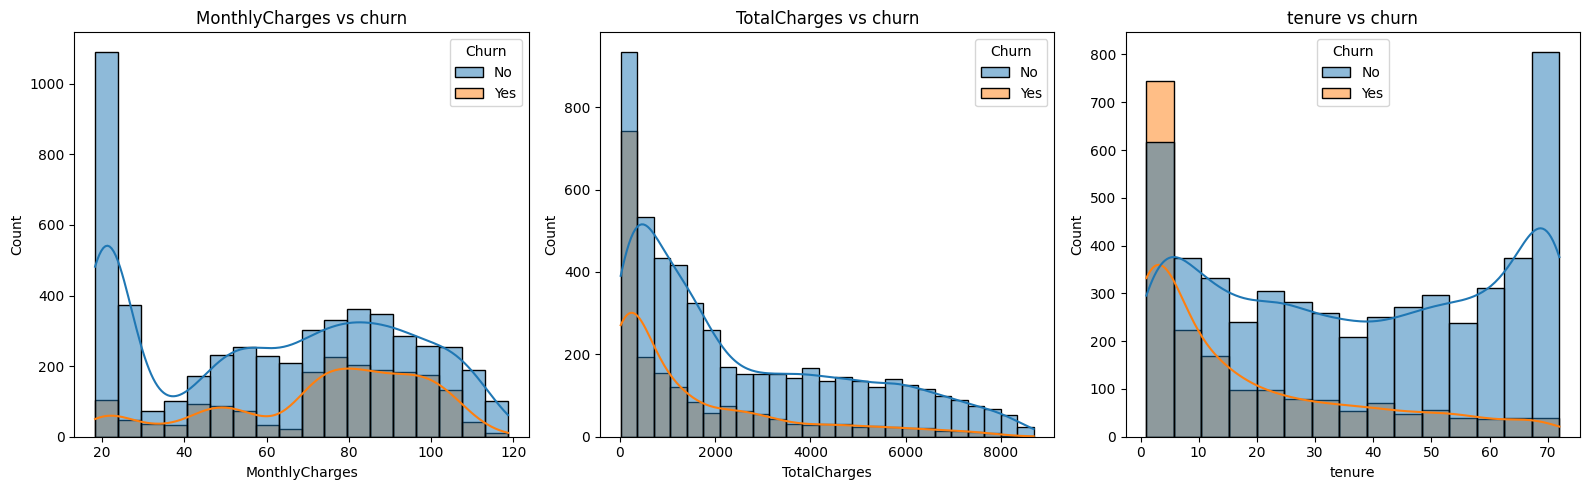

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(16,5))
for i,col in enumerate(num_cols):
  sns.histplot(data=df,x=col,hue="Churn",kde=True,ax=axes[i])
  axes[i].set_title(f"{col} vs churn")
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

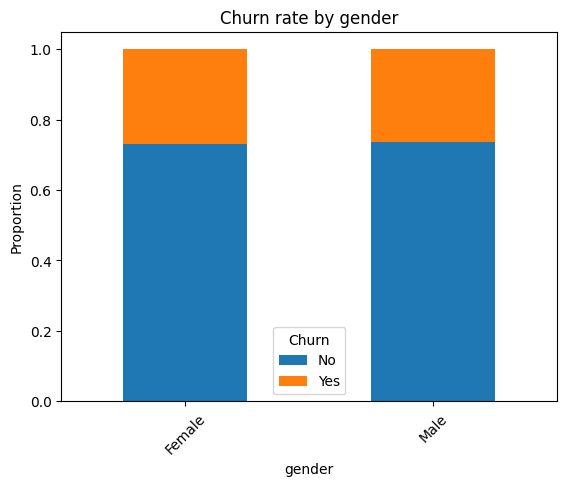

<Figure size 600x400 with 0 Axes>

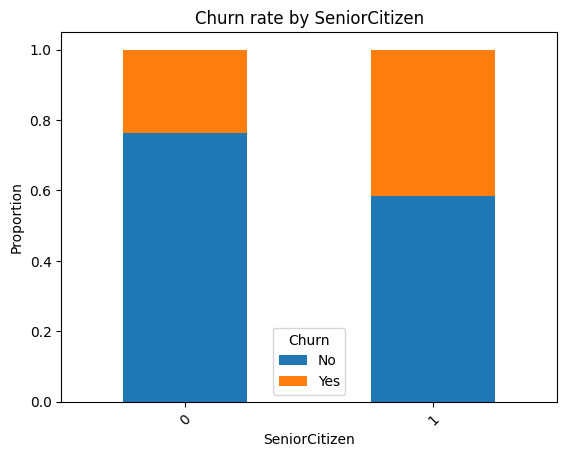

<Figure size 600x400 with 0 Axes>

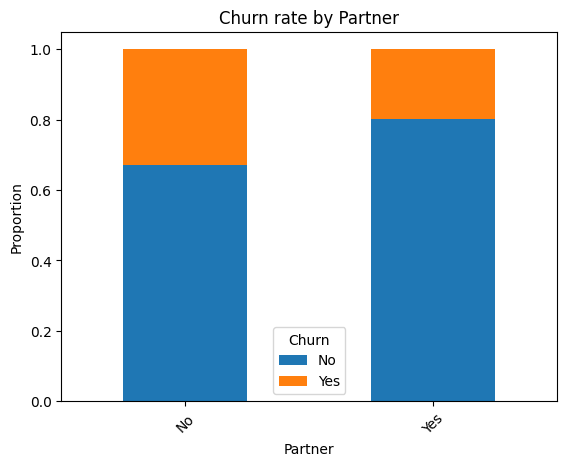

<Figure size 600x400 with 0 Axes>

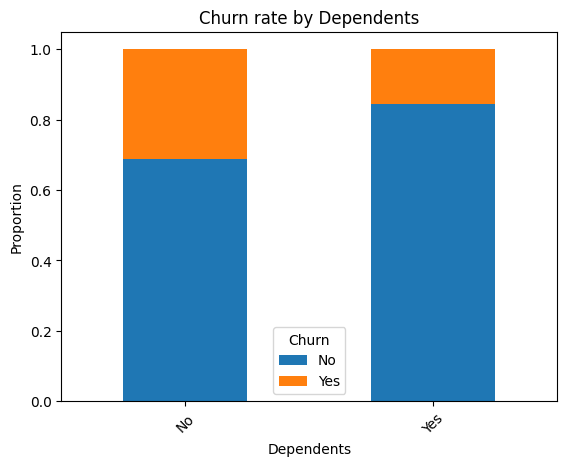

<Figure size 600x400 with 0 Axes>

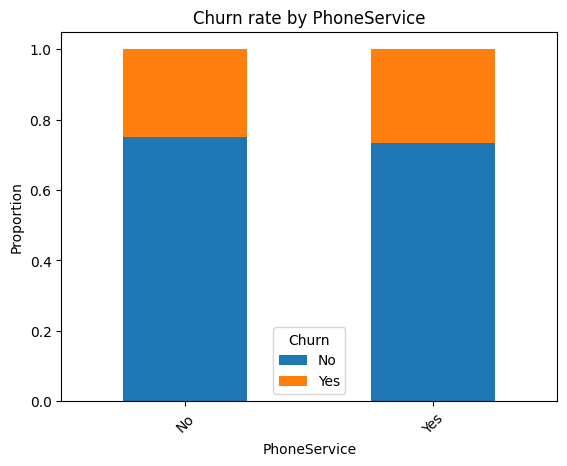

<Figure size 600x400 with 0 Axes>

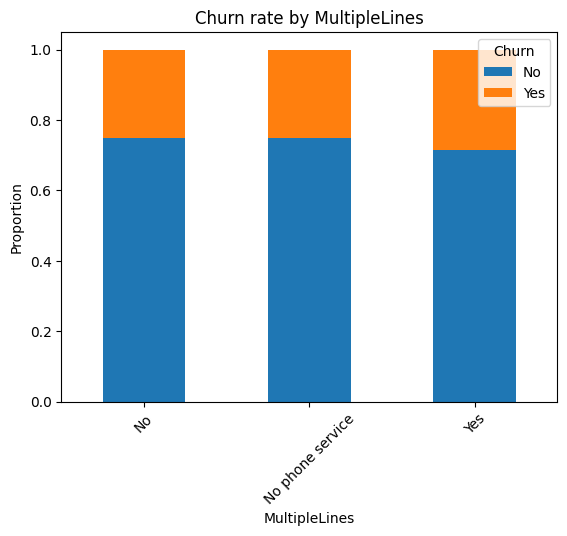

<Figure size 600x400 with 0 Axes>

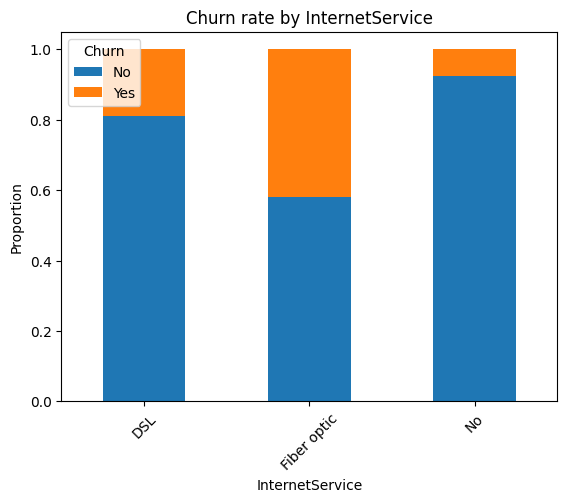

<Figure size 600x400 with 0 Axes>

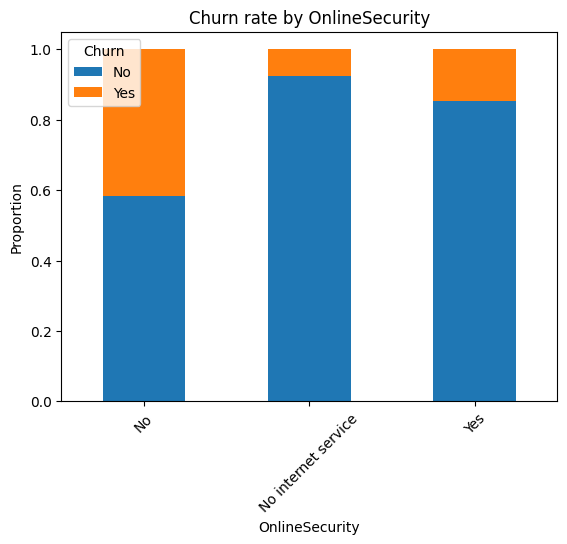

<Figure size 600x400 with 0 Axes>

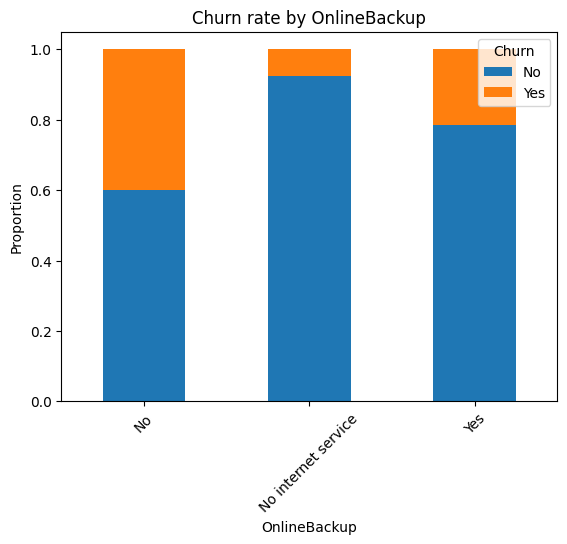

<Figure size 600x400 with 0 Axes>

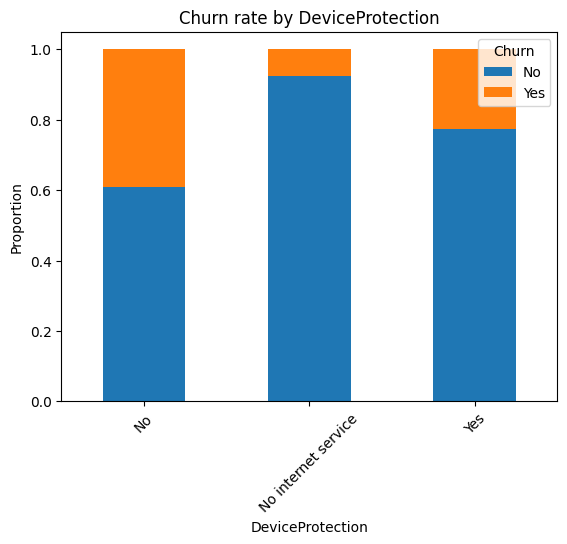

<Figure size 600x400 with 0 Axes>

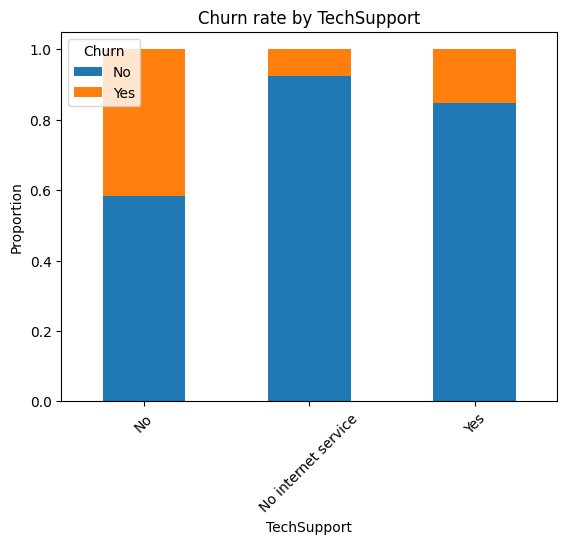

<Figure size 600x400 with 0 Axes>

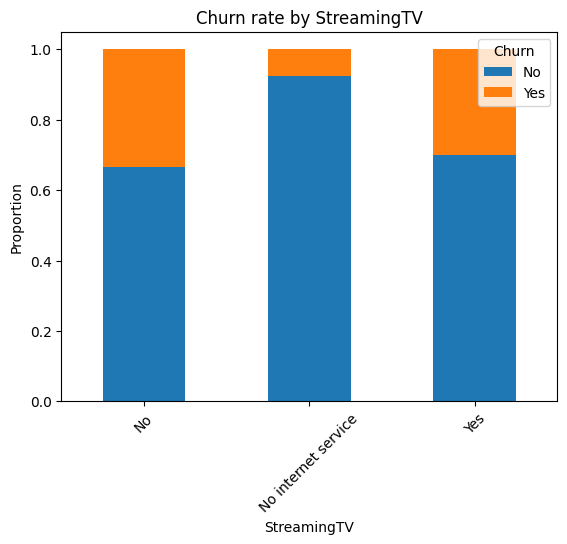

<Figure size 600x400 with 0 Axes>

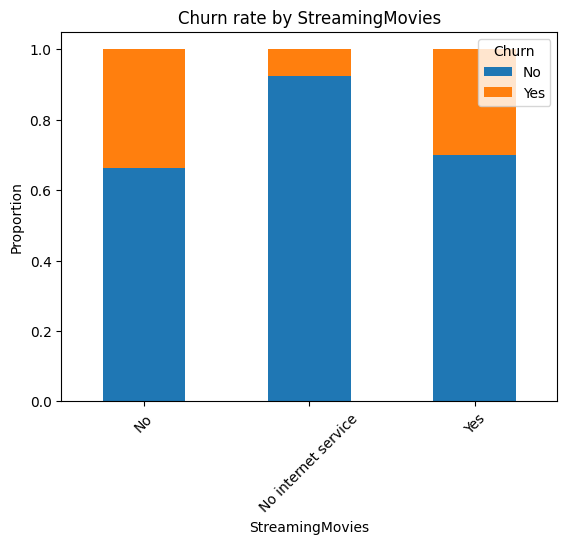

<Figure size 600x400 with 0 Axes>

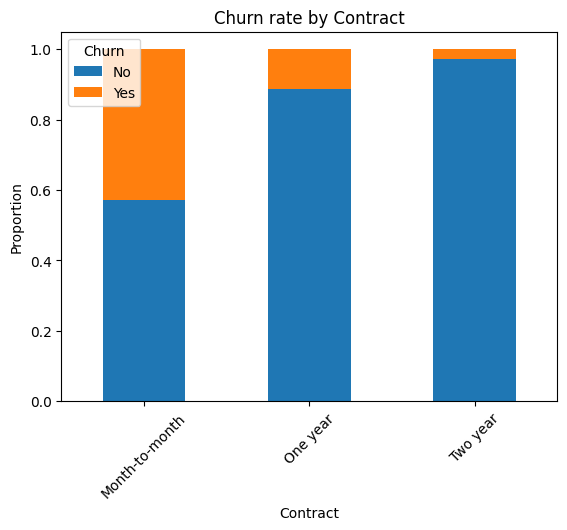

<Figure size 600x400 with 0 Axes>

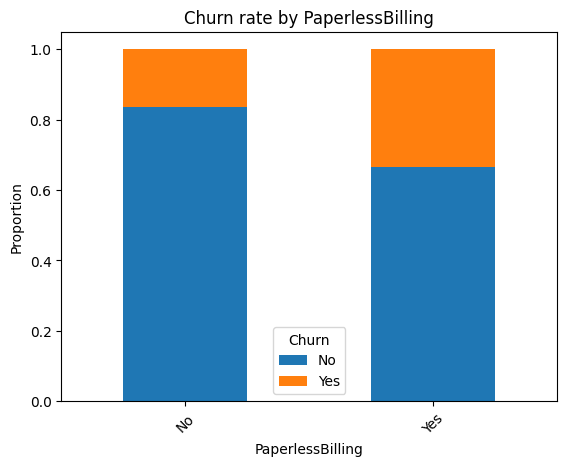

<Figure size 600x400 with 0 Axes>

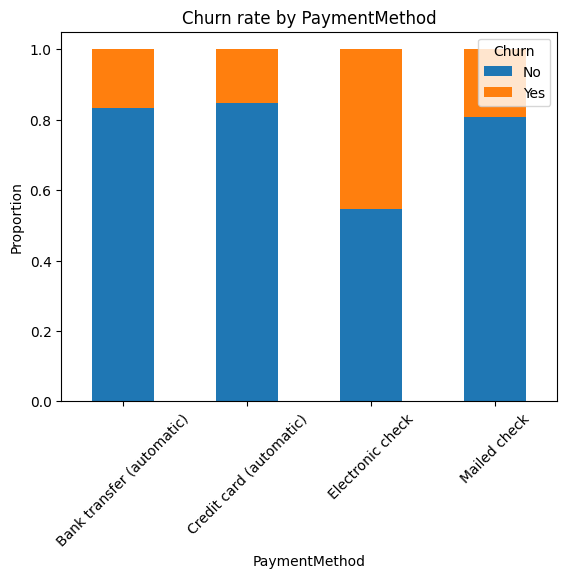

In [31]:
for col in cat_cols:
  plt.figure(figsize=(6,4))
  churn_rate=pd.crosstab(df[col],df['Churn'],normalize='index')
  churn_rate.plot(kind='bar',stacked=True)
  plt.title(f"Churn rate by {col}")
  plt.ylabel("Proportion")
  plt.xticks(rotation=45)
  plt.show()

In [32]:
df=df.drop("customerID",axis=1)
df["Churn"]=df["Churn"].map({'No':0,'Yes':1})
X=df.drop("Churn",axis=1)
y=df["Churn"]
X=pd.get_dummies(X,drop_first=True)
print(X.shape)
X.head()

(7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [33]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [34]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

BaseLine Model

In [35]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(class_weight="balanced",random_state=42,max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [37]:
from sklearn.metrics import (accuracy_score,roc_auc_score,precision_score,recall_score,confusion_matrix,classification_report,f1_score)
y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.7256574271499645
Precision: 0.4900990099009901
Recall: 0.7941176470588235
F1 Score: 0.6061224489795919
ROC AUC: 0.8353440733857567

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [39]:
print(confusion_matrix(y_test,y_pred))

[[724 309]
 [ 77 297]]


Random Forest model

In [44]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

class_weight='balanced'
This parameter tells the model to automatically adjust the weights of the different classes when learning from the training data. It assigns a higher penalty to misclassifying the minority class and a lower penalty to misclassifying the majority class.

In [45]:
y_pred_rf=model.predict(X_test)
y_prob_rf=model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test,y_pred_rf))
print("Recall:", recall_score(y_test,y_pred_rf))
print("F1_score:", f1_score(y_test,y_pred_rf))
print("Precision:", precision_score(y_test,y_pred_rf))
print("ROC and AUC:", roc_auc_score(y_test,y_prob_rf))
print(confusion_matrix(y_test,y_pred_rf))
print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7818052594171997
Recall: 0.660427807486631
F1_score: 0.616729088639201
Precision: 0.5784543325526932
ROC and AUC: 0.831935176605184
[[853 180]
 [127 247]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1033
           1       0.58      0.66      0.62       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.79      1407



In [47]:
import joblib
joblib.dump(model, 'logistic_regression_churn_predictor.pkl')
print("Logistic Regression model saved as 'logistic_regression_churn_predictor.pkl'")

Logistic Regression model saved as 'logistic_regression_churn_predictor.pkl'


In [48]:
joblib.dump(rf_model, 'random_forest_churn_predictor.pkl')
print("Random Forest model saved as 'random_forest_churn_predictor.pkl'")

Random Forest model saved as 'random_forest_churn_predictor.pkl'
